# 04C — Modèles avec 5 folds  
## House Prices: Advanced Regression Techniques

Ce notebook est la **dernière étape** du pipeline Kaggle. Il charge les matrices produites par le notebook 03, entraîne plusieurs modèles, compare leurs performances en validation croisée, construit un blend optimisé, ajoute un stacking léger, puis génère le fichier final :

```text
final_submission_cv.csv
```




## Plan du notebook

1. Initialisation des librairies et constantes  
2. Chargement des features finales produites par le notebook 03  
3. Définition de la métrique RMSE  
4. Définition des modèles de base  
5. Entraînement Out-of-Fold des modèles  
6. Analyse visuelle des performances  
7. Blend optimisé par pondération  
8. Stacking niveau 2  
9. Assemblage final des prédictions  
10. Export du fichier Kaggle

La métrique principale est la **RMSE sur `log1p(SalePrice)`**, comme dans la compétition Kaggle House Prices.


## 1. Initialisation

On importe les librairies nécessaires pour :

- manipuler les matrices numériques ;
- entraîner les modèles ;
- calculer la RMSE ;
- faire le blending et le stacking ;
- produire des visualisations d'audit.




In [1]:
import sys
import subprocess
import importlib.util
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



import numpy as np
import pandas as pd

from scipy.special import boxcox1p
from scipy.stats import skew
from scipy.optimize import minimize

from sklearn.base import clone
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import Ridge, LassoCV, ElasticNetCV
from sklearn.ensemble import (
    GradientBoostingRegressor, ExtraTreesRegressor,
    HistGradientBoostingRegressor
)
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


N_SPLITS = 5  
LINEAR_CV_FOLDS = 3
STRATIFIED_PRICE_FOLDS = True
RUN_OPTUNA = True
OPTUNA_N_TRIALS = 100
OPTUNA_TUNING_FOLDS = 5


GBR_EST = 1200
XGB_EST = 1600
LGB_EST = 1600
CAT_ITER = 1600
HGB_ITER = 350
EXTRA_EST = 250

# Style graphique léger pour rendre les visualisations lisibles.
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Initialisation terminée :', datetime.now())
print('Mode CV amélioré | N_SPLITS:', N_SPLITS, '| LINEAR_CV_FOLDS:', LINEAR_CV_FOLDS, '| Stratified:', STRATIFIED_PRICE_FOLDS)
print('Tailles des modèles boosting :', {
    'gbr': GBR_EST, 'xgb': XGB_EST, 'lgb': LGB_EST,
    'cat': CAT_ITER, 'hgb': HGB_ITER, 'extra': EXTRA_EST
})

Initialisation terminée : 2026-05-16 01:04:22.896464
Mode CV amélioré | N_SPLITS: 5 | LINEAR_CV_FOLDS: 3 | Stratified: True
Tailles des modèles boosting : {'gbr': 1200, 'xgb': 1600, 'lgb': 1600, 'cat': 1600, 'hgb': 350, 'extra': 250}


## 2. Chargement des données préparées

Ce notebook ne refait pas le preprocessing ni le feature engineering. Il charge directement le fichier produit par le notebook 03 :

```text
house_prices_stage2_features.pkl
```

Ce fichier contient :

- `X` : matrice d'entraînement finale ;
- `X_sub` : matrice test finale ;
- `y` : cible transformée en `log1p(SalePrice)` ;
- `test_ID` : identifiants nécessaires pour le fichier Kaggle.


In [2]:

STAGE2_PATH = None

def find_artifact(filename, manual_path=None):
    """Find an intermediate pickle file saved by a previous notebook."""
    if manual_path is not None:
        manual_path = Path(manual_path).expanduser().resolve()
        if manual_path.exists():
            return manual_path
        raise FileNotFoundError(f'Manual artifact path does not exist: {manual_path}')

    current = Path.cwd().resolve()
    priority_paths = [
        current / filename,
        current / 'outputs' / filename,
        current / 'artifacts' / filename,
        current / 'data' / filename,
    ]

    for p in priority_paths:
        if p.exists():
            return p

    try:
        matches = list(current.rglob(filename))
        if matches:
            return matches[0]
    except Exception:
        pass

    raise FileNotFoundError(
        f'Could not find {filename}. Run Notebook 03 first, or set STAGE2_PATH manually.'
    )

stage2_path = find_artifact('house_prices_stage2_features.pkl', STAGE2_PATH)
print('Chargement du fichier Stage 2 :', stage2_path)

stage2 = pd.read_pickle(stage2_path)

X = stage2['X'].copy()
X_sub = stage2['X_sub'].copy()
y = stage2['y'].copy()
test_ID = stage2['test_ID'].copy()
test_n_rows = stage2['test_n_rows']
DATA_DIR = Path(stage2.get('DATA_DIR', Path.cwd()))


# Récupération des paramètres sauvegardés par les notebooks précédents.
RANDOM_STATE = stage2.get('RANDOM_STATE', RANDOM_STATE)
N_SPLITS = 5  
LINEAR_CV_FOLDS = stage2.get('LINEAR_CV_FOLDS', LINEAR_CV_FOLDS)
STRATIFIED_PRICE_FOLDS = stage2.get('STRATIFIED_PRICE_FOLDS', STRATIFIED_PRICE_FOLDS)
np.random.seed(RANDOM_STATE)

print('Taille X train :', X.shape)
print('Taille X test  :', X_sub.shape)
print('Taille y       :', y.shape)

assert X.shape[0] == len(y), 'Training rows and target length do not match'
assert X_sub.shape[0] == test_n_rows, 'Test row count mismatch'


Chargement du fichier Stage 2 : C:\Users\souma\OneDrive\Bureau\proj ML\projet\final\house_prices_stage2_features.pkl
Taille X train : (1458, 444)
Taille X test  : (1459, 444)
Taille y       : (1458,)


### 2.1 Audit rapide des matrices

Avant d'entraîner les modèles, on vérifie que les matrices sont propres :

- pas de valeurs manquantes ;
- pas de valeurs infinies ;
- même nombre de colonnes entre train et test ;
- distribution de la cible log cohérente.

Ces contrôles ne changent rien aux données : ils servent à sécuriser le pipeline.


In [3]:
# Contrôles qualité sur les matrices finales
missing_train = int(X.isna().sum().sum())
missing_test  = int(X_sub.isna().sum().sum())
inf_train = int(np.isinf(X.to_numpy(dtype=float)).sum())
inf_test  = int(np.isinf(X_sub.to_numpy(dtype=float)).sum())

controle_df = pd.DataFrame({
    'élément': ['X train', 'X test', 'y'],
    'lignes': [X.shape[0], X_sub.shape[0], len(y)],
    'colonnes': [X.shape[1], X_sub.shape[1], 1],
    'valeurs_manquantes': [missing_train, missing_test, int(y.isna().sum())],
    'valeurs_infinies': [inf_train, inf_test, int(np.isinf(y).sum())]
})

display(controle_df)

print('Nombre total de variables utilisées par les modèles :', X.shape[1])
print('Les colonnes train/test sont identiques :', list(X.columns) == list(X_sub.columns))
print('RMSE sera calculée sur la cible log1p(SalePrice).')

,élément,lignes,colonnes,valeurs_manquantes,valeurs_infinies
0,X train,1458,444,0,0
1,X test,1459,444,0,0
2,y,1458,1,0,0


Nombre total de variables utilisées par les modèles : 444
Les colonnes train/test sont identiques : True
RMSE sera calculée sur la cible log1p(SalePrice).


### 2.2 Visualisation de la cible utilisée par les modèles

Les modèles ne prédisent pas directement `SalePrice`, mais `log1p(SalePrice)`.  
Cela stabilise la variance et rend les erreurs relatives plus équilibrées entre maisons peu chères et maisons chères.


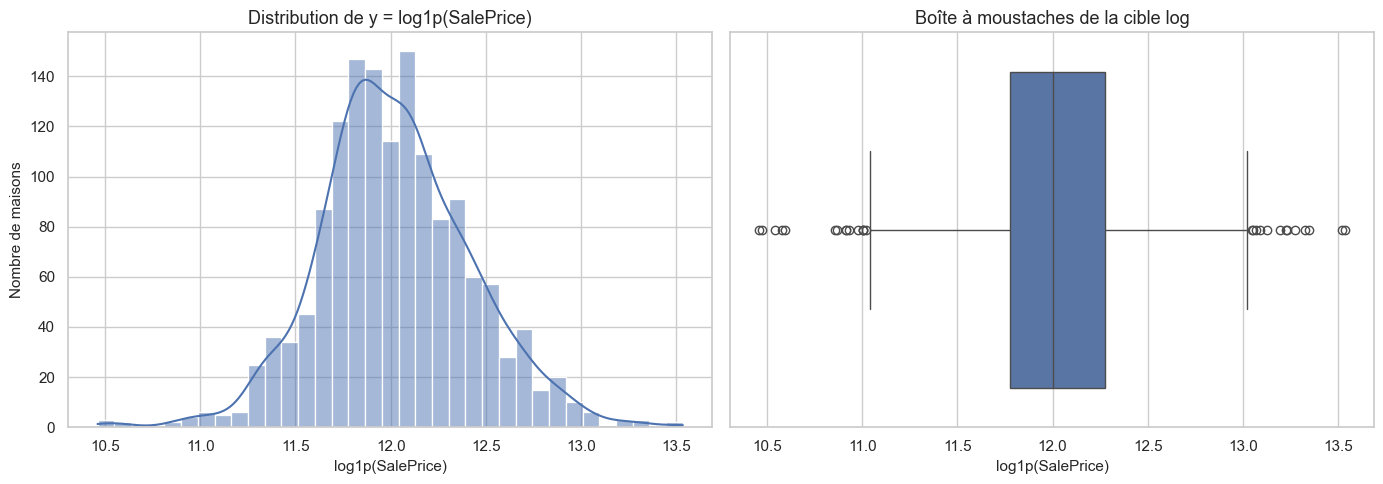

Interprétation : une cible log plus régulière aide surtout les modèles linéaires et réduit l'impact des prix extrêmes.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(y, kde=True, bins=35, ax=axes[0])
axes[0].set_title('Distribution de y = log1p(SalePrice)')
axes[0].set_xlabel('log1p(SalePrice)')
axes[0].set_ylabel('Nombre de maisons')

sns.boxplot(x=y, ax=axes[1])
axes[1].set_title('Boîte à moustaches de la cible log')
axes[1].set_xlabel('log1p(SalePrice)')

plt.tight_layout()
plt.show()

print("Interprétation : une cible log plus régulière aide surtout les modèles linéaires et réduit l'impact des prix extrêmes.")

## 3. Fonction d'évaluation

La compétition évalue les prédictions via une erreur de type RMSE sur les prix transformés en log.  
Ici, on utilise la même logique pour comparer les modèles localement.


In [5]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(np.asarray(y_true), np.asarray(y_pred))))

print('Fonction RMSE prête.')

Fonction RMSE prête.


## 4. Définition des modèles

On utilise plusieurs familles de modèles afin de capturer des relations différentes :

- **Ridge / LassoCV / ElasticNetCV** : modèles linéaires régularisés, solides sur les données tabulaires avec beaucoup de variables encodées ;
- **Gradient Boosting, XGBoost, LightGBM, CatBoost, HistGradientBoosting** : modèles d'arbres boostés, efficaces pour capturer des non-linéarités ;
- **ExtraTrees** : modèle d'arbres aléatoires, utile comme source de diversité dans l'ensemble.

L'intérêt n'est pas seulement d'avoir le meilleur modèle individuel, mais d'obtenir des erreurs différentes entre modèles pour améliorer le blend final.


In [6]:
# Stratification de la cible continue : on découpe y en 5 classes de prix.
y_binned = pd.qcut(pd.Series(y).rank(method='first'), q=5, labels=False, duplicates='drop')

if STRATIFIED_PRICE_FOLDS:
    kfolds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    print('CV utilisé : StratifiedKFold sur prix binned | folds =', N_SPLITS)
else:
    kfolds = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    print('CV utilisé : KFold classique | folds =', N_SPLITS)

print('Nombre estimateurs :', dict(
    gbr=GBR_EST, xgb=XGB_EST, lgb=LGB_EST,
    cat=CAT_ITER, hgb=HGB_ITER, extra=EXTRA_EST
))

# ── Modèles linéaires avec validation croisée interne, conservés mais optimisés ───────────────────────────────
# Important :
# LassoCV / ElasticNetCV à l'intérieur d'une validation OOF créent un entraînement imbriqué.
# Pour garder ces modèles sans rendre le notebook trop lent, on utilise :
# - petites grilles d'alpha
# - cv=3 en interne
# - n_jobs=-1
# - max_iter réduit mais suffisant
# - precompute='auto'

ridge = make_pipeline(
    RobustScaler(),
    Ridge(alpha=10.0)
)

lasso = make_pipeline(
    RobustScaler(),
    LassoCV(
        alphas=[0.0003, 0.0005, 0.0007, 0.001],
        cv=LINEAR_CV_FOLDS,
        max_iter=8000,
        tol=1e-4,
        random_state=RANDOM_STATE,
        selection='random',
        precompute='auto',
        n_jobs=-1
    )
)

elastic = make_pipeline(
    RobustScaler(),
    ElasticNetCV(
        alphas=[0.0003, 0.0005, 0.0007, 0.001],
        l1_ratio=[0.5, 0.7, 0.9],
        cv=LINEAR_CV_FOLDS,
        max_iter=8000,
        tol=1e-4,
        random_state=RANDOM_STATE,
        selection='random',
        precompute='auto',
        n_jobs=-1
    )
)

# ── Modèles arbres / boosting ──────────────────────────────────────────────────────
gbr = GradientBoostingRegressor(
    n_estimators=GBR_EST,
    learning_rate=0.015,
    max_depth=3,
    max_features='sqrt',
    min_samples_leaf=15,
    min_samples_split=10,
    loss='huber',
    random_state=RANDOM_STATE
)

xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=XGB_EST,
    learning_rate=0.012,
    max_depth=3,
    min_child_weight=3,
    gamma=0.01,
    subsample=0.70,
    colsample_bytree=0.60,
    reg_alpha=0.001,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist'
)

lgb = LGBMRegressor(
    objective='regression',
    n_estimators=LGB_EST,
    learning_rate=0.012,
    num_leaves=20,
    max_depth=4,
    bagging_fraction=0.75,
    bagging_freq=5,
    bagging_seed=RANDOM_STATE,
    feature_fraction=0.45,
    feature_fraction_seed=RANDOM_STATE,
    min_data_in_leaf=20,
    lambda_l1=0.001,
    lambda_l2=0.3,
    verbose=-1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cat = CatBoostRegressor(
    iterations=CAT_ITER,
    learning_rate=0.02,
    depth=5,
    l2_leaf_reg=3,
    bagging_temperature=0.7,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

hgb = HistGradientBoostingRegressor(
    max_iter=HGB_ITER,
    learning_rate=0.025,
    max_depth=5,
    min_samples_leaf=20,
    l2_regularization=0.1,
    max_bins=255,
    random_state=RANDOM_STATE
)

extra = ExtraTreesRegressor(
    n_estimators=EXTRA_EST,
    max_features=0.45,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)


# ── Réseau de neurones simple : diversité supplémentaire ──────────────────────────
# Le MLP apprend des patterns différents des arbres/boosting. On le standardise car il
# est sensible à l'échelle des variables.
mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=25,
        random_state=RANDOM_STATE
    )
)

models = {
    'ridge': ridge,
    'lassocv': lasso,
    'elasticnetcv': elastic,
    'gbr': gbr,
    'xgb': xgb,
    'lgb': lgb,
    'cat': cat,
    'hgb': hgb,
    'extra': extra,
    'mlp': mlp,
}

print('Modèles prêts :', list(models.keys()))
print('Nombre total de fit niveau 0 :', len(models) * N_SPLITS)
print('Fit internes approximatifs LassoCV :', N_SPLITS * LINEAR_CV_FOLDS * 4)
print('Fit internes approximatifs ElasticNetCV :', N_SPLITS * LINEAR_CV_FOLDS * 4 * 3)


CV utilisé : StratifiedKFold sur prix binned | folds = 5
Nombre estimateurs : {'gbr': 1200, 'xgb': 1600, 'lgb': 1600, 'cat': 1600, 'hgb': 350, 'extra': 250}
Modèles prêts : ['ridge', 'lassocv', 'elasticnetcv', 'gbr', 'xgb', 'lgb', 'cat', 'hgb', 'extra', 'mlp']
Nombre total de fit niveau 0 : 50
Fit internes approximatifs LassoCV : 60
Fit internes approximatifs ElasticNetCV : 180


### 4.1 Vue synthétique des modèles

Ce tableau aide à expliquer le rôle de chaque modèle dans l'ensemble.  
Il est purement descriptif : il ne modifie ni l'entraînement ni les prédictions.


In [7]:
model_summary = pd.DataFrame({
    'modèle': list(models.keys()),
    'famille': [
        'Linéaire régularisé',
        'Linéaire régularisé avec sélection',
        'Linéaire régularisé mixte',
        'Boosting sklearn',
        'Boosting gradient XGBoost',
        'Boosting gradient LightGBM',
        'Boosting gradient CatBoost',
        'Boosting histogramme sklearn',
        'Forêt très aléatoire',
        'Réseau de neurones MLP'
    ],
    'rôle dans l’ensemble': [
        'Base stable et robuste',
        'Réduit les variables inutiles',
        'Compromis Ridge/Lasso',
        'Capture des non-linéarités',
        'Modèle puissant tabulaire',
        'Modèle rapide et performant',
        'Bon sur données tabulaires',
        'Alternative boosting rapide',
        'Diversifie les prédictions',
        'Ajoute une erreur différente des arbres'
    ]
})

display(model_summary)
print("Interprétation : l'objectif n'est pas que chaque modèle soit le meilleur seul, mais que leurs erreurs soient complémentaires.")

,modèle,famille,rôle dans l’ensemble
0,ridge,Linéaire régularisé,Base stable et robuste
1,lassocv,Linéaire régularisé avec sélection,Réduit les variables inutiles
2,elasticnetcv,Linéaire régularisé mixte,Compromis Ridge/Lasso
3,gbr,Boosting sklearn,Capture des non-linéarités
4,xgb,Boosting gradient XGBoost,Modèle puissant tabulaire
5,lgb,Boosting gradient LightGBM,Modèle rapide et performant
6,cat,Boosting gradient CatBoost,Bon sur données tabulaires
7,hgb,Boosting histogramme sklearn,Alternative boosting rapide
8,extra,Forêt très aléatoire,Diversifie les prédictions
9,mlp,Réseau de neurones MLP,Ajoute une erreur différente des arbres


Interprétation : l'objectif n'est pas que chaque modèle soit le meilleur seul, mais que leurs erreurs soient complémentaires.


## 5.1 Optimisation Optuna de LightGBM et XGBoost

Cette étape remplace le tuning manuel par une recherche automatique d'hyperparamètres.

- `RUN_OPTUNA = True` lance la recherche.
- `OPTUNA_N_TRIALS = 100` suit la recommandation demandée.
- La recherche utilise une CV stratifiée sur des bins de prix pour stabiliser la comparaison.




In [8]:
import sys
print(sys.executable)

c:\Users\souma\anaconda3\python.exe


In [9]:
!{sys.executable} -m pip install optuna

In [10]:
def cv_rmse_model(model, X, y, cv, y_bins=None):
    """Calcule une RMSE CV pour Optuna sans data leakage."""
    scores = []
    if isinstance(cv, StratifiedKFold):
        split_iter = cv.split(X, y_bins)
    else:
        split_iter = cv.split(X, y)

    for tr_idx, val_idx in split_iter:
        est = clone(model)
        est.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = est.predict(X.iloc[val_idx])
        scores.append(rmse(y.iloc[val_idx], pred))
    return float(np.mean(scores))


try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except Exception as e:
    optuna = None
    print('Optuna non disponible. Installe-le avec : pip install optuna')
    print('Erreur :', e)


if RUN_OPTUNA and optuna is not None:
    tune_folds = StratifiedKFold(
        n_splits=min(OPTUNA_TUNING_FOLDS, N_SPLITS),
        shuffle=True,
        random_state=RANDOM_STATE
    )
    tune_bins = pd.qcut(pd.Series(y).rank(method='first'), q=5, labels=False, duplicates='drop')

    print(f'Démarrage Optuna LightGBM + XGBoost | trials = {OPTUNA_N_TRIALS}')

    def objective_lgb(trial):
        params = {
            'objective': 'regression',
            'n_estimators': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 8, 63),
            'max_depth': trial.suggest_int('max_depth', 2, 6),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 0.85),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.55, 0.95),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 8),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 60),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-5, 2.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
            'verbose': -1,
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
        }
        model = LGBMRegressor(**params)
        return cv_rmse_model(model, X, y, tune_folds, tune_bins)

    study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_lgb.optimize(objective_lgb, n_trials=OPTUNA_N_TRIALS, show_progress_bar=False)
    print('Best LGB RMSE Optuna:', study_lgb.best_value)
    print('Best LGB params:', study_lgb.best_params)

    best_lgb_params = dict(study_lgb.best_params)
    best_lgb_params.update({
        'objective': 'regression',
        'n_estimators': 2500,
        'verbose': -1,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
    })
    models['lgb'] = LGBMRegressor(**best_lgb_params)

    def objective_xgb(trial):
        params = {
            'objective': 'reg:squarederror',
            'n_estimators': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.04, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 5),
            'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 8.0),
            'subsample': trial.suggest_float('subsample', 0.55, 0.95),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.45, 0.90),
            'gamma': trial.suggest_float('gamma', 1e-5, 0.2, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 12.0, log=True),
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
            'tree_method': 'hist',
        }
        model = XGBRegressor(**params)
        return cv_rmse_model(model, X, y, tune_folds, tune_bins)

    study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 1))
    study_xgb.optimize(objective_xgb, n_trials=OPTUNA_N_TRIALS, show_progress_bar=False)
    print('Best XGB RMSE Optuna:', study_xgb.best_value)
    print('Best XGB params:', study_xgb.best_params)

    best_xgb_params = dict(study_xgb.best_params)
    best_xgb_params.update({
        'objective': 'reg:squarederror',
        'n_estimators': 2500,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'tree_method': 'hist',
    })
    models['xgb'] = XGBRegressor(**best_xgb_params)

else:
    print('Optuna désactivé ou indisponible : utilisation des hyperparamètres manuels.')


Démarrage Optuna LightGBM + XGBoost | trials = 100
Best LGB RMSE Optuna: 0.11412803449833242
Best LGB params: {'learning_rate': 0.009336032349247814, 'num_leaves': 12, 'max_depth': 4, 'feature_fraction': 0.5312197325379421, 'bagging_fraction': 0.5673775526797404, 'bagging_freq': 6, 'min_data_in_leaf': 14, 'lambda_l1': 0.00010240513577389802, 'lambda_l2': 0.005201159971148002}
Best XGB RMSE Optuna: 0.11236434867984901
Best XGB params: {'learning_rate': 0.030819445189075843, 'max_depth': 2, 'min_child_weight': 3.499473970359656, 'subsample': 0.6352453867035373, 'colsample_bytree': 0.4642192091322827, 'gamma': 0.013412133764749968, 'reg_alpha': 0.32016735946385916, 'reg_lambda': 0.5243902885348101}


## 5. Entraînement Out-of-Fold des modèles

On entraîne chaque modèle avec une validation croisée à 5 folds.

Principe :

1. Le modèle est entraîné sur 4 folds ;
2. il prédit le fold restant ;
3. on répète l'opération 5 fois ;
4. on obtient une prédiction OOF pour chaque ligne d'entraînement ;
5. les prédictions test sont moyennées sur les 5 folds.

Cette méthode donne une estimation plus fiable de la performance qu'une simple séparation train/validation.


In [11]:
import time

def get_oof_and_test_predictions(models, X, y, X_sub, cv):
    oof_preds  = pd.DataFrame(index=X.index)
    test_preds = pd.DataFrame(index=X_sub.index)
    scores = []
    failed_models = []

    total_start = time.time()

    for name, model in models.items():
        model_start = time.time()
        print(f'\n========== {name.upper()} ==========')
        oof = np.zeros(X.shape[0], dtype=float)
        sub = np.zeros(X_sub.shape[0], dtype=float)
        fold_scores = []
        model_failed = False

        try:
            if isinstance(cv, StratifiedKFold):
                split_iter = cv.split(X, y_binned)
            else:
                split_iter = cv.split(X, y)

            for fold, (tr_idx, val_idx) in enumerate(split_iter, 1):
                fold_start = time.time()

                X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
                y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

                est = clone(model)
                est.fit(X_tr, y_tr)

                val_pred  = np.asarray(est.predict(X_val),  dtype=float)
                test_pred = np.asarray(est.predict(X_sub), dtype=float)

                if not np.isfinite(val_pred).all() or not np.isfinite(test_pred).all():
                    raise ValueError(f'{name} produced non-finite predictions.')

                oof[val_idx] = val_pred
                sub += test_pred / cv.get_n_splits()

                fold_rmse = rmse(y_val, val_pred)
                fold_scores.append(fold_rmse)
                print(f'  Fold {fold:02d}: RMSE={fold_rmse:.5f} | {time.time() - fold_start:.1f}s')

        except Exception as e:
            model_failed = True
            failed_models.append((name, str(e)))
            print(f'  MODÈLE IGNORÉ : {e}')

        if not model_failed:
            model_rmse = rmse(y, oof)
            oof_preds[name]  = oof
            test_preds[name] = sub
            scores.append({
                'model': name,
                'oof_rmse': model_rmse,
                'fold_mean': np.mean(fold_scores),
                'fold_std': np.std(fold_scores),
                'time_min': (time.time() - model_start) / 60
            })
            print(f'{name} RMSE OOF : {model_rmse:.6f}')
            print(f'{name} durée    : {(time.time() - model_start) / 60:.1f} min')

    scores_df = pd.DataFrame(scores).sort_values('oof_rmse').reset_index(drop=True)

    print('\nDurée totale OOF :', round((time.time() - total_start) / 60, 1), 'min')

    if failed_models:
        print('\nModèles échoués :')
        for n, err in failed_models:
            print(f'- {n}: {err}')

    return oof_preds, test_preds, scores_df


oof_preds, test_preds, scores_df = get_oof_and_test_predictions(models, X, y, X_sub, kfolds)

print('\nClassement OOF des modèles :')
display(scores_df)


========== RIDGE ==========
  Fold 01: RMSE=0.11549 | 0.2s
  Fold 02: RMSE=0.10415 | 0.1s
  Fold 03: RMSE=0.09904 | 0.1s
  Fold 04: RMSE=0.12081 | 0.1s
  Fold 05: RMSE=0.12502 | 0.1s
ridge RMSE OOF : 0.113316
ridge durée    : 0.0 min

========== LASSOCV ==========
  Fold 01: RMSE=0.11048 | 0.4s
  Fold 02: RMSE=0.10295 | 0.3s
  Fold 03: RMSE=0.09495 | 0.3s
  Fold 04: RMSE=0.11826 | 0.3s
  Fold 05: RMSE=0.12562 | 0.3s
lassocv RMSE OOF : 0.110970
lassocv durée    : 0.0 min

========== ELASTICNETCV ==========
  Fold 01: RMSE=0.11039 | 0.9s
  Fold 02: RMSE=0.10320 | 0.5s
  Fold 03: RMSE=0.09504 | 1.0s
  Fold 04: RMSE=0.11813 | 1.0s
  Fold 05: RMSE=0.12533 | 0.8s
elasticnetcv RMSE OOF : 0.110919
elasticnetcv durée    : 0.1 min

========== GBR ==========
  Fold 01: RMSE=0.12064 | 6.4s
  Fold 02: RMSE=0.10139 | 4.4s
  Fold 03: RMSE=0.09727 | 4.7s
  Fold 04: RMSE=0.11091 | 4.0s
  Fold 05: RMSE=0.13138 | 5.5s
gbr RMSE OOF : 0.112999
gbr durée    : 0.4 min

========== XGB ==========
  Fold 01: R

,model,oof_rmse,fold_mean,fold_std,time_min
0,elasticnetcv,0.110919,0.110419,0.010684,0.069883
1,lassocv,0.110970,0.110455,0.010839,0.026188
2,cat,0.111608,0.111082,0.010956,1.280110
3,gbr,0.112999,0.112318,0.012494,0.417419
4,xgb,0.113051,0.112503,0.011268,0.801257
5,ridge,0.113316,0.112902,0.009846,0.009940
6,lgb,0.114828,0.114359,0.010512,0.240271
7,hgb,0.122928,0.122544,0.009844,0.806657
8,extra,0.124506,0.123644,0.014745,0.207261
9,mlp,0.714242,0.712578,0.048574,0.890158


## 6. Analyse des performances des modèles de base

Après l'entraînement, on visualise :

- le classement RMSE OOF ;
- la stabilité des modèles entre folds ;
- le temps d'entraînement ;
- les résidus des meilleurs modèles.



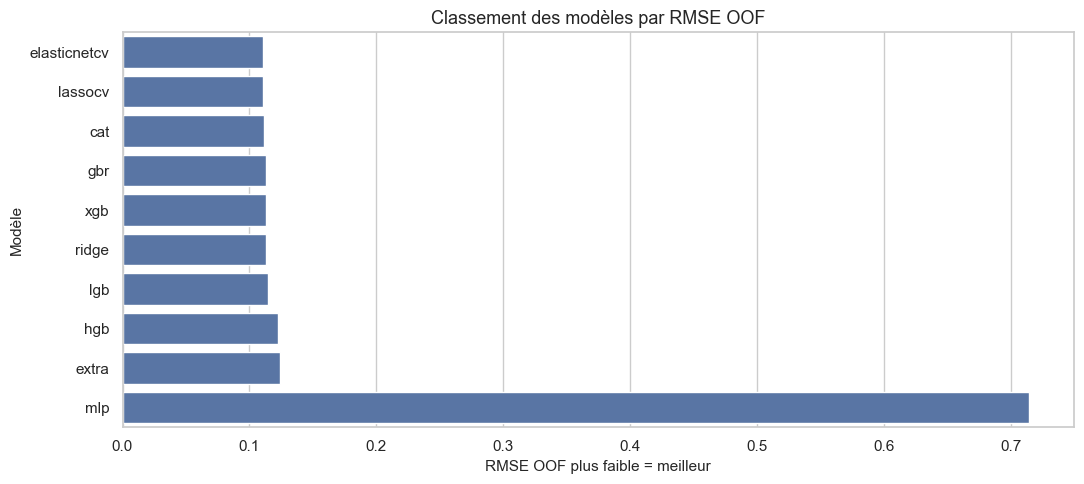

Meilleur modèle individuel : elasticnetcv avec RMSE OOF = 0.110919
Interprétation : le meilleur modèle seul n'est pas forcément le meilleur choix final ; le blend peut être meilleur grâce à la complémentarité.


In [12]:
# Sécurité : on ne trace les graphiques que si au moins un modèle a réussi.
if len(scores_df) == 0:
    raise RuntimeError("Aucun modèle n'a été entraîné correctement. Vérifie les erreurs affichées plus haut.")

scores_plot = scores_df.copy().sort_values('oof_rmse', ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=scores_plot, x='oof_rmse', y='model', ax=ax)
ax.set_title('Classement des modèles par RMSE OOF')
ax.set_xlabel('RMSE OOF plus faible = meilleur')
ax.set_ylabel('Modèle')
plt.tight_layout()
plt.show()

best_model_name = scores_plot.iloc[0]['model']
best_model_rmse = scores_plot.iloc[0]['oof_rmse']
print(f"Meilleur modèle individuel : {best_model_name} avec RMSE OOF = {best_model_rmse:.6f}")
print("Interprétation : le meilleur modèle seul n'est pas forcément le meilleur choix final ; le blend peut être meilleur grâce à la complémentarité.")

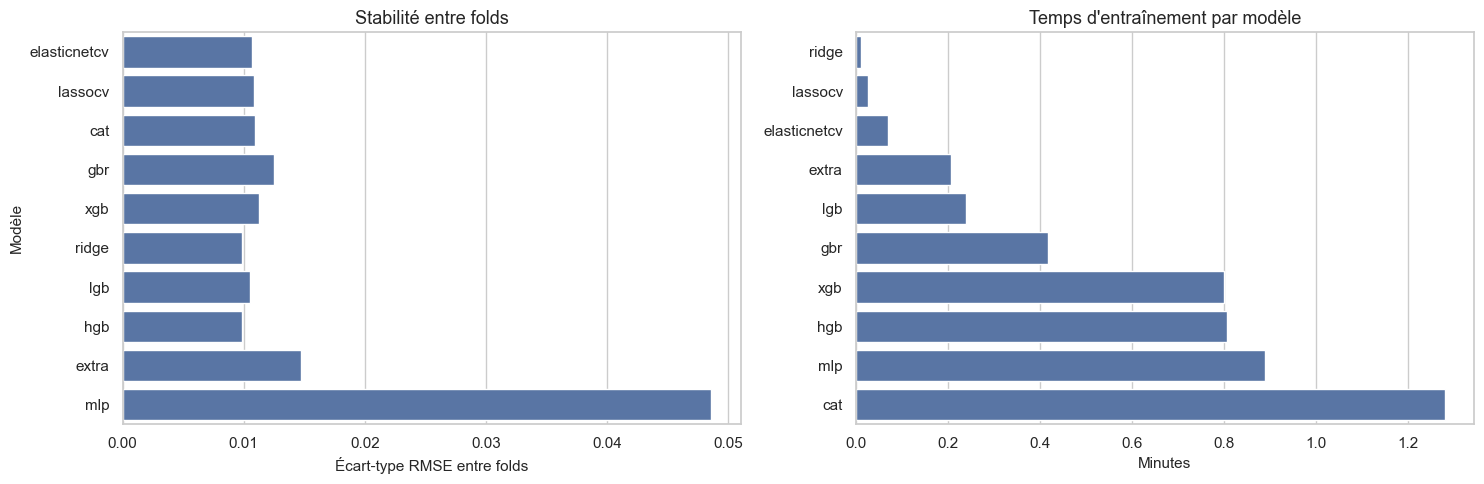

Interprétation : un bon modèle doit être performant, mais aussi stable. Un écart-type élevé peut indiquer une sensibilité aux folds.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=scores_plot, x='fold_std', y='model', ax=axes[0])
axes[0].set_title('Stabilité entre folds')
axes[0].set_xlabel('Écart-type RMSE entre folds')
axes[0].set_ylabel('Modèle')

sns.barplot(data=scores_plot.sort_values('time_min', ascending=True), x='time_min', y='model', ax=axes[1])
axes[1].set_title("Temps d'entraînement par modèle")
axes[1].set_xlabel('Minutes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Interprétation : un bon modèle doit être performant, mais aussi stable. Un écart-type élevé peut indiquer une sensibilité aux folds.")

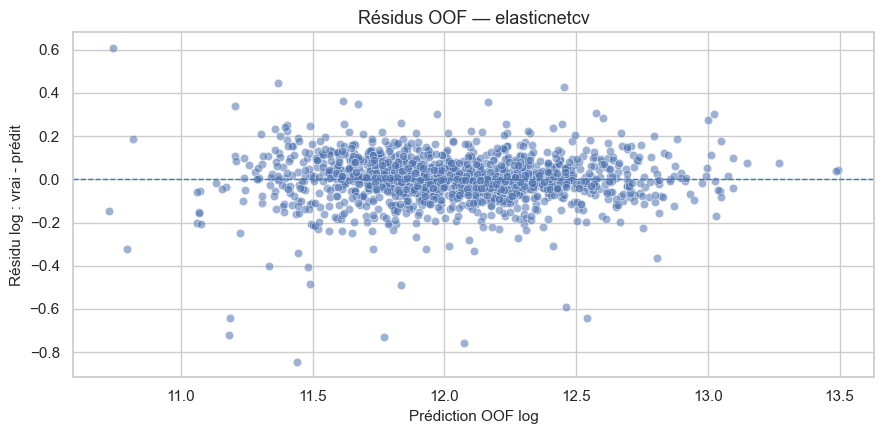

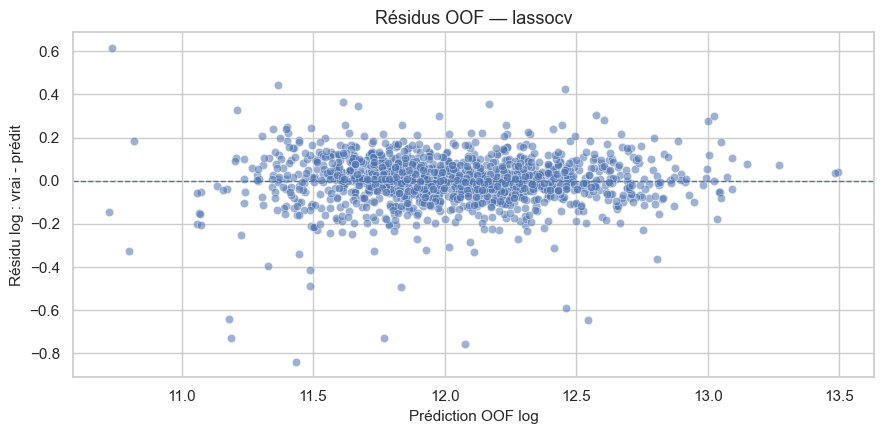

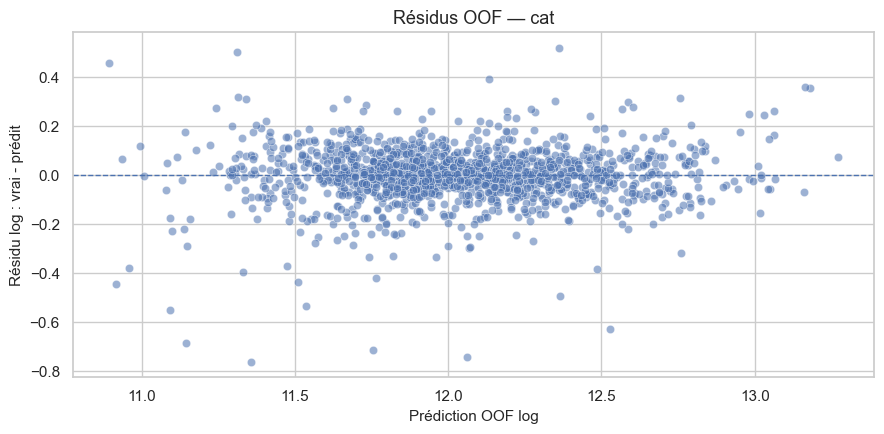

Interprétation : des résidus centrés autour de 0 indiquent une absence de biais global important.
Si les résidus sont plus grands pour les prix élevés, le modèle a plus de difficulté sur les maisons très chères.


In [14]:
# Analyse des résidus pour les meilleurs modèles individuels
# Résidu = vraie valeur log - prédiction OOF log

top_models_for_residuals = scores_plot['model'].head(min(3, len(scores_plot))).tolist()

residual_df = pd.DataFrame({'y_true': y})
for m in top_models_for_residuals:
    residual_df[f'resid_{m}'] = y - oof_preds[m]

for m in top_models_for_residuals:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.scatterplot(x=oof_preds[m], y=residual_df[f'resid_{m}'], alpha=0.55, ax=ax)
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_title(f'Résidus OOF — {m}')
    ax.set_xlabel('Prédiction OOF log')
    ax.set_ylabel('Résidu log : vrai - prédit')
    plt.tight_layout()
    plt.show()

print("Interprétation : des résidus centrés autour de 0 indiquent une absence de biais global important.")
print("Si les résidus sont plus grands pour les prix élevés, le modèle a plus de difficulté sur les maisons très chères.")

## 7. Blend optimisé par pondération

Le blend combine les prédictions OOF des modèles de base.  
L'optimisation cherche les poids qui minimisent la RMSE OOF :

```text
prediction_finale = w1 × modèle1 + w2 × modèle2 + ... + wk × modèlek
```

Contraintes :

- chaque poids est entre 0 et 1 ;
- la somme des poids vaut 1.




In [15]:
model_names = list(oof_preds.columns)
P = oof_preds[model_names].to_numpy(dtype=float)
T = test_preds[model_names].to_numpy(dtype=float)

assert np.isfinite(P).all(), 'OOF matrix has non-finite values'
assert np.isfinite(T).all(), 'Test pred matrix has non-finite values'


def blend_rmse(weights, P, y_array):
    return rmse(y_array, np.dot(P, weights))


n_models        = len(model_names)
initial_weights = np.ones(n_models) / n_models
bounds          = [(0, 1)] * n_models
constraints     = ({'type': 'eq', 'fun': lambda w: w.sum() - 1})

result = minimize(
    blend_rmse, initial_weights, args=(P, y.values),
    method='SLSQP', bounds=bounds, constraints=constraints,
    options={'maxiter': 2000, 'ftol': 1e-14}
)

optimized_weights = result.x if (result.success and np.isfinite(result.fun)) \
    else initial_weights

blend_oof  = np.dot(P, optimized_weights)
blend_test = np.dot(T, optimized_weights)
blend_score = rmse(y, blend_oof)

weights_df = pd.DataFrame({'model': model_names, 'weight': optimized_weights})
weights_df = weights_df.sort_values('weight', ascending=False).reset_index(drop=True)

print(f'RMSE OOF du blend optimisé : {blend_score:.6f}')
display(weights_df)

RMSE OOF du blend optimisé : 0.107813


,model,weight
0,elasticnetcv,4.182976e-01
1,gbr,2.375621e-01
2,cat,1.287373e-01
3,xgb,1.221074e-01
4,ridge,7.284007e-02
5,lgb,1.993140e-02
6,mlp,5.240837e-04
7,lassocv,2.123493e-16
8,extra,1.285437e-17
9,hgb,1.199980e-17


### 7.1 Interprétation des poids du blend

Les poids montrent quels modèles sont les plus utiles dans l'ensemble optimisé.  
Un poids faible ne signifie pas forcément que le modèle est mauvais : il peut simplement apporter une information déjà couverte par d'autres modèles.


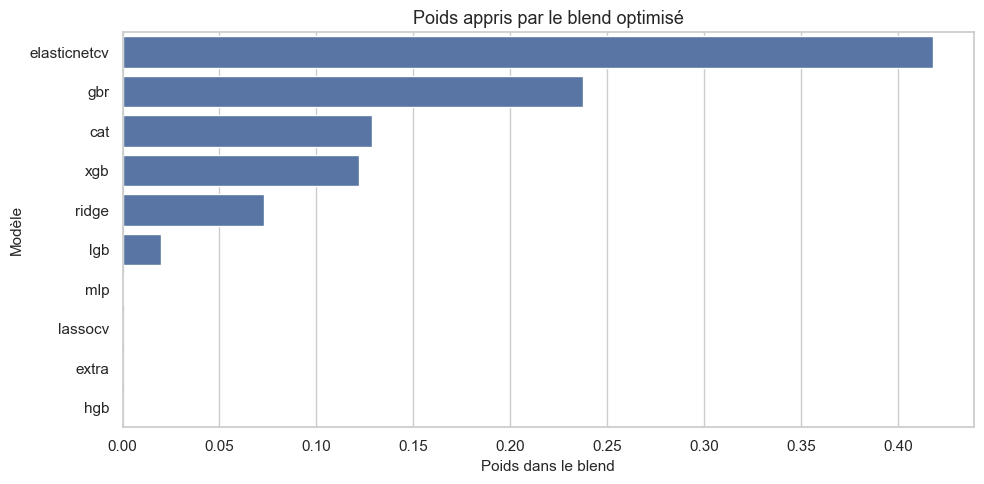

,approche,rmse_oof
0,Meilleur modèle individuel,0.110919
1,Blend optimisé,0.107813


Gain du blend vs meilleur modèle individuel : 0.003106 RMSE log
Interprétation : le blend améliore la validation OOF, donc les modèles sont complémentaires.


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=weights_df, x='weight', y='model', ax=ax)
ax.set_title('Poids appris par le blend optimisé')
ax.set_xlabel('Poids dans le blend')
ax.set_ylabel('Modèle')
plt.tight_layout()
plt.show()

comparison_blend_df = pd.DataFrame({
    'approche': ['Meilleur modèle individuel', 'Blend optimisé'],
    'rmse_oof': [best_model_rmse, blend_score]
})

display(comparison_blend_df)

improvement = best_model_rmse - blend_score
print(f"Gain du blend vs meilleur modèle individuel : {improvement:.6f} RMSE log")

if improvement > 0:
    print("Interprétation : le blend améliore la validation OOF, donc les modèles sont complémentaires.")
else:
    print("Interprétation : le blend n'améliore pas le meilleur modèle individuel sur OOF, mais il peut rester plus robuste.")

## 8. Stacking niveau 2

Le stacking ajoute une deuxième couche de modèle.  
Les méta-modèles apprennent à combiner :

- les prédictions des modèles de base ;
- les meilleures variables brutes sélectionnées par information mutuelle.

L'objectif est de laisser un modèle de niveau 2 apprendre quand faire confiance à tel ou tel modèle de base.


In [17]:
from sklearn.feature_selection import mutual_info_regression

# Sélection des meilleures variables brutes par information mutuelle
TOP_RAW_FEATURES = 25

print(f'Calcul de l’information mutuelle sur {X.shape[1]} variables...')
mi_scores = mutual_info_regression(
    X.astype(np.float32), y,
    random_state=RANDOM_STATE,
    n_neighbors=5
)
top_raw_idx  = np.argsort(mi_scores)[::-1][:TOP_RAW_FEATURES]
top_raw_cols = X.columns[top_raw_idx].tolist()
print('Variables brutes sélectionnées :', top_raw_cols)

# Construction des matrices de méta-features
X_meta_train = np.hstack([P, X[top_raw_cols].to_numpy(dtype=float)])
X_meta_test  = np.hstack([T, X_sub[top_raw_cols].to_numpy(dtype=float)])

meta_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def meta_oof_predict(model, X_meta_train, y, X_meta_test, cv, name):
    oof = np.zeros(X_meta_train.shape[0], dtype=float)
    test_pred = np.zeros(X_meta_test.shape[0], dtype=float)

    if isinstance(cv, StratifiedKFold):
        split_iter = cv.split(X_meta_train, y_binned)
    else:
        split_iter = cv.split(X_meta_train, y)

    for fold, (tr_idx, val_idx) in enumerate(split_iter, 1):
        est = clone(model)
        est.fit(X_meta_train[tr_idx], y.iloc[tr_idx])

        oof[val_idx] = est.predict(X_meta_train[val_idx])
        test_pred += est.predict(X_meta_test) / cv.get_n_splits()

        print(f'  {name} fold {fold}: {rmse(y.iloc[val_idx], oof[val_idx]):.5f}')

    score = rmse(y, oof)
    print(f'{name} OOF RMSE: {score:.6f}')
    return oof, test_pred, score

# Méta-modèle rapide 1 : Ridge
ridge_meta = make_pipeline(
    RobustScaler(),
    Ridge(alpha=5.0)
)

ridge_meta_oof, ridge_meta_test, ridge_meta_score = meta_oof_predict(
    ridge_meta, X_meta_train, y, X_meta_test, meta_cv, 'Ridge meta'
)

# Méta-modèle rapide 2 : LightGBM petit et régularisé
lgb_meta = LGBMRegressor(
    objective='regression',
    n_estimators=300,
    learning_rate=0.04,
    num_leaves=8,
    max_depth=3,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    min_data_in_leaf=15,
    lambda_l1=0.001,
    lambda_l2=0.5,
    verbose=-1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lgb_meta_oof, lgb_meta_test, lgb_meta_score = meta_oof_predict(
    lgb_meta, X_meta_train, y, X_meta_test, meta_cv, 'LGB meta'
)

# Méta-modèle 3 : XGBoost régularisé
xgb_meta = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist'
)

xgb_meta_oof, xgb_meta_test, xgb_meta_score = meta_oof_predict(
    xgb_meta, X_meta_train, y, X_meta_test, meta_cv, 'XGB meta'
)

# Combinaison demandée des trois méta-modèles
meta_weighted_oof  = 0.5 * ridge_meta_oof + 0.3 * lgb_meta_oof + 0.2 * xgb_meta_oof
meta_weighted_test = 0.5 * ridge_meta_test + 0.3 * lgb_meta_test + 0.2 * xgb_meta_test
meta_weighted_score = rmse(y, meta_weighted_oof)

print(f'\nRMSE OOF blend      : {blend_score:.6f}')
print(f'RMSE Ridge meta     : {ridge_meta_score:.6f}')
print(f'RMSE LGB meta       : {lgb_meta_score:.6f}')
print(f'RMSE XGB meta       : {xgb_meta_score:.6f}')
print(f'RMSE Meta weighted  : {meta_weighted_score:.6f}')

Calcul de l’information mutuelle sur 444 variables...
Variables brutes sélectionnées : ['NeighborhoodQual_TotalSF', 'OverallQual_TotalSF', 'TotalQual_TotalSF', 'ExterQual_TotalSF', 'OverallQual_GrLivArea', 'OverallQual_TotalBath', 'TotalSF_Sqrt', 'TotalSF', 'KitchenQual_GrLivArea', 'TotalLivArea', 'TotalSF_Sq', 'OverallQual_YearBuilt', 'GarageCars_OverallQual', 'TotalQualityScore', 'OverallQual_Sq', 'OverallQual_GarageArea', 'OverallQual', 'OverallQual_Sqrt', 'Neigh_MedianPrice_OOF', 'Neighborhood_TE', 'Neigh_MeanPrice_OOF', 'Neigh_MeanQual', 'GrLivArea', 'GrLivArea_sq', 'GrLivArea_Sqrt']
  Ridge meta fold 1: 0.11253
  Ridge meta fold 2: 0.09908
  Ridge meta fold 3: 0.09431
  Ridge meta fold 4: 0.11667
  Ridge meta fold 5: 0.12493
Ridge meta OOF RMSE: 0.110069
  LGB meta fold 1: 0.12083
  LGB meta fold 2: 0.10800
  LGB meta fold 3: 0.10671
  LGB meta fold 4: 0.12467
  LGB meta fold 5: 0.12702
LGB meta OOF RMSE: 0.117739
  XGB meta fold 1: 0.11993
  XGB meta fold 2: 0.10832
  XGB meta f

### 8.1 Analyse des variables utilisées par le stacking

Les variables sélectionnées par information mutuelle sont celles qui ont le plus de relation statistique avec la cible.  
Elles sont utilisées en plus des prédictions des modèles de base pour enrichir le méta-modèle.


,variable,mutual_information
0,NeighborhoodQual_TotalSF,0.938203
1,OverallQual_TotalSF,0.938196
2,TotalQual_TotalSF,0.877789
3,ExterQual_TotalSF,0.815141
4,OverallQual_GrLivArea,0.764078
5,OverallQual_TotalBath,0.690670
6,TotalSF_Sqrt,0.685869
7,TotalSF,0.684609
8,KitchenQual_GrLivArea,0.676157
9,TotalLivArea,0.674974


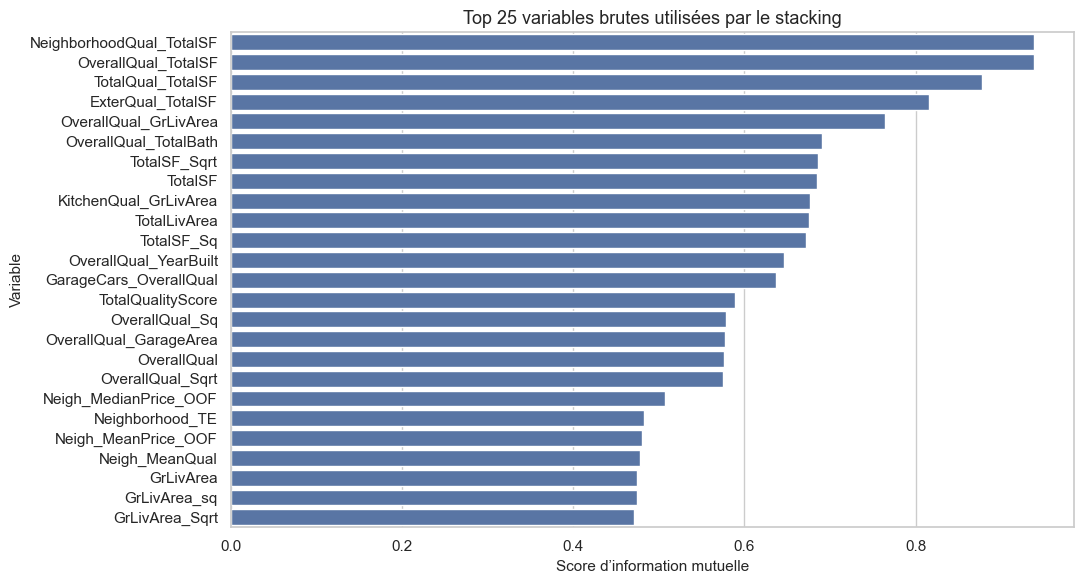

Interprétation : ces variables aident le méta-modèle à corriger le blend selon des signaux forts comme la qualité, la surface ou le quartier.


In [18]:
mi_df = pd.DataFrame({
    'variable': X.columns,
    'mutual_information': mi_scores
}).sort_values('mutual_information', ascending=False).reset_index(drop=True)

display(mi_df.head(TOP_RAW_FEATURES))

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=mi_df.head(TOP_RAW_FEATURES), x='mutual_information', y='variable', ax=ax)
ax.set_title(f'Top {TOP_RAW_FEATURES} variables brutes utilisées par le stacking')
ax.set_xlabel('Score d’information mutuelle')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

print("Interprétation : ces variables aident le méta-modèle à corriger le blend selon des signaux forts comme la qualité, la surface ou le quartier.")

,approche,rmse_oof
0,Blend optimisé,0.107813
1,Ridge meta,0.110069
4,Meta pondéré 0.5/0.3/0.2,0.112036
3,XGB meta,0.116765
2,LGB meta,0.117739


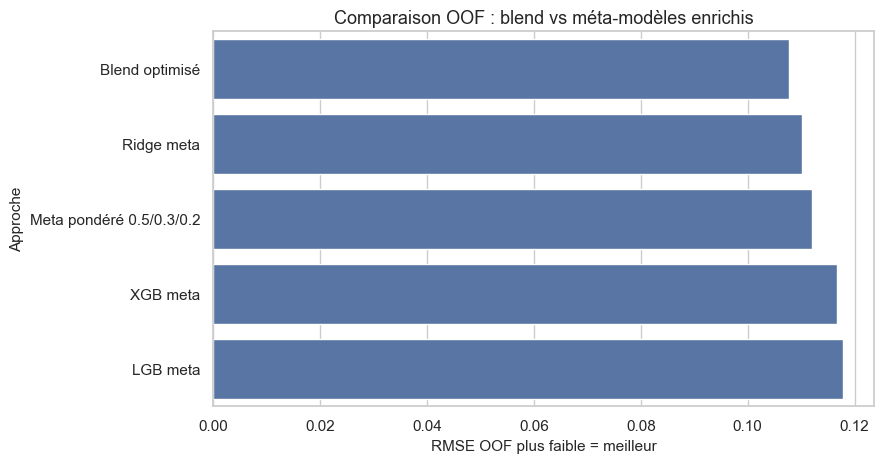

Interprétation : le méta-modèle pondéré ajoute XGBoost comme troisième apprenant de niveau 1.
On reste conservateur dans la prédiction finale pour éviter que le stacking overfitte le train.


In [19]:
stacking_comparison = pd.DataFrame({
    'approche': ['Blend optimisé', 'Ridge meta', 'LGB meta', 'XGB meta', 'Meta pondéré 0.5/0.3/0.2'],
    'rmse_oof': [blend_score, ridge_meta_score, lgb_meta_score, xgb_meta_score, meta_weighted_score]
}).sort_values('rmse_oof')

display(stacking_comparison)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=stacking_comparison, x='rmse_oof', y='approche', ax=ax)
ax.set_title('Comparaison OOF : blend vs méta-modèles enrichis')
ax.set_xlabel('RMSE OOF plus faible = meilleur')
ax.set_ylabel('Approche')
plt.tight_layout()
plt.show()

print("Interprétation : le méta-modèle pondéré ajoute XGBoost comme troisième apprenant de niveau 1.")
print("On reste conservateur dans la prédiction finale pour éviter que le stacking overfitte le train.")

## 9. Assemblage final des prédictions

Le notebook utilise une stratégie **conservatrice** :

- si le stacking est nettement meilleur que le blend, il reçoit plus de poids ;
- sinon, on garde principalement le blend optimisé.

Cette décision limite le risque de surapprentissage du méta-modèle.


In [20]:
best_meta_score = min(ridge_meta_score, lgb_meta_score, xgb_meta_score, meta_weighted_score)

# Ensemble conservateur de niveau 2 :
# - le blend optimisé reste le signal le plus stable ;
# - le stacking enrichi est intégré davantage seulement s'il bat clairement le blend.
if meta_weighted_score < blend_score - 0.0005:
    final_log_pred = 0.70 * blend_test + 0.30 * meta_weighted_test
    strategy = '70% blend optimisé + 30% meta pondéré Ridge/LGB/XGB'
else:
    final_log_pred = 0.80 * blend_test + 0.20 * meta_weighted_test
    strategy = '80% blend optimisé + 20% meta pondéré Ridge/LGB/XGB'

print('Stratégie finale :', strategy)
print(f'RMSE blend OOF         : {blend_score:.6f}')
print(f'RMSE meta pondéré OOF  : {meta_weighted_score:.6f}')

# Clipping en espace log : bornes plus strictes sur les percentiles 1% et 99%.
# Cela évite que quelques prédictions extrêmes pénalisent le RMSLE Kaggle.
low_clip  = np.percentile(y, 1)
high_clip = np.percentile(y, 99)
final_log_pred = np.clip(final_log_pred, low_clip, high_clip)

# Conversion des prédictions log vers les prix réels et suppression des valeurs négatives.
final_prices = np.clip(np.expm1(final_log_pred), 0, None)

print(f'Clipping log-space : [{low_clip:.4f}, {high_clip:.4f}]')
print(f'\nIntervalle des prédictions : ${final_prices.min():,.0f} – ${final_prices.max():,.0f}')
print(f'Moyenne prédite          : ${final_prices.mean():,.0f}')


Stratégie finale : 80% blend optimisé + 20% meta pondéré Ridge/LGB/XGB
RMSE blend OOF         : 0.107813
RMSE meta pondéré OOF  : 0.112036
Clipping log-space : [11.0314, 13.0006]

Intervalle des prédictions : $61,785 – $442,681
Moyenne prédite          : $177,913


### 9.1 Distribution des prédictions finales

On vérifie que les prix prédits sont réalistes et qu'il n'y a pas de valeurs extrêmes anormales.


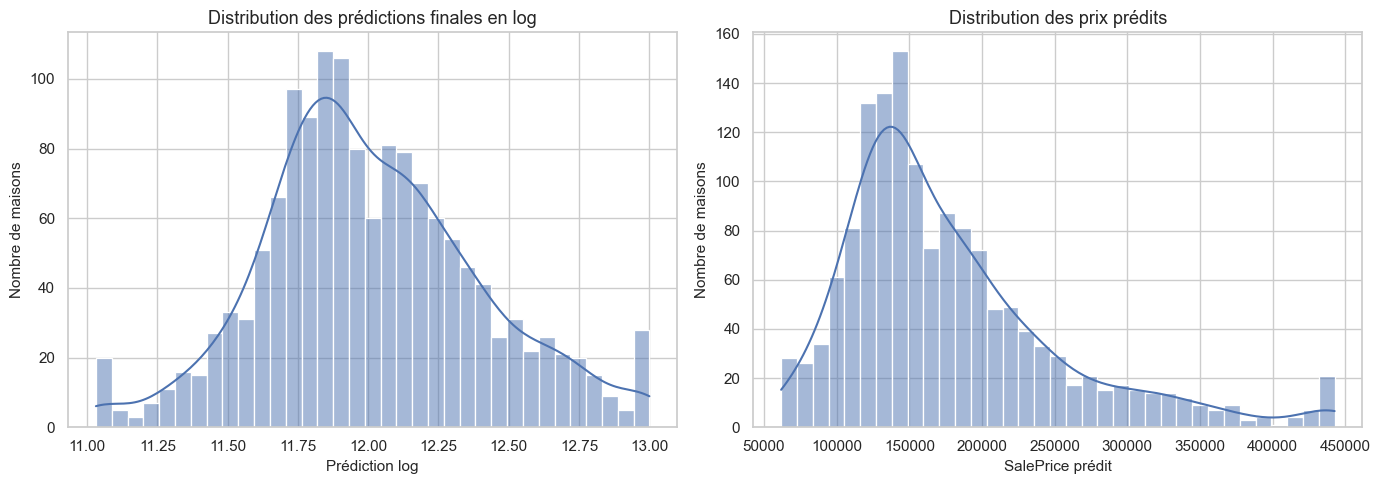

count      1459.0
mean     177913.0
std       75550.0
min       61785.0
1%        62388.0
5%        90188.0
50%      156289.0
95%      337915.0
99%      442681.0
max      442681.0
Name: SalePrice prédit, dtype: float64

Interprétation : on cherche une distribution cohérente, sans prix négatifs ni valeurs absurdes.
Le clipping en log-space évite que quelques prédictions extrêmes pénalisent fortement la soumission.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(final_log_pred, kde=True, bins=35, ax=axes[0])
axes[0].set_title('Distribution des prédictions finales en log')
axes[0].set_xlabel('Prédiction log')
axes[0].set_ylabel('Nombre de maisons')

sns.histplot(final_prices, kde=True, bins=35, ax=axes[1])
axes[1].set_title('Distribution des prix prédits')
axes[1].set_xlabel('SalePrice prédit')
axes[1].set_ylabel('Nombre de maisons')

plt.tight_layout()
plt.show()

pred_summary = pd.Series(final_prices, name='SalePrice prédit').describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(0)
display(pred_summary)

print("Interprétation : on cherche une distribution cohérente, sans prix négatifs ni valeurs absurdes.")
print("Le clipping en log-space évite que quelques prédictions extrêmes pénalisent fortement la soumission.")

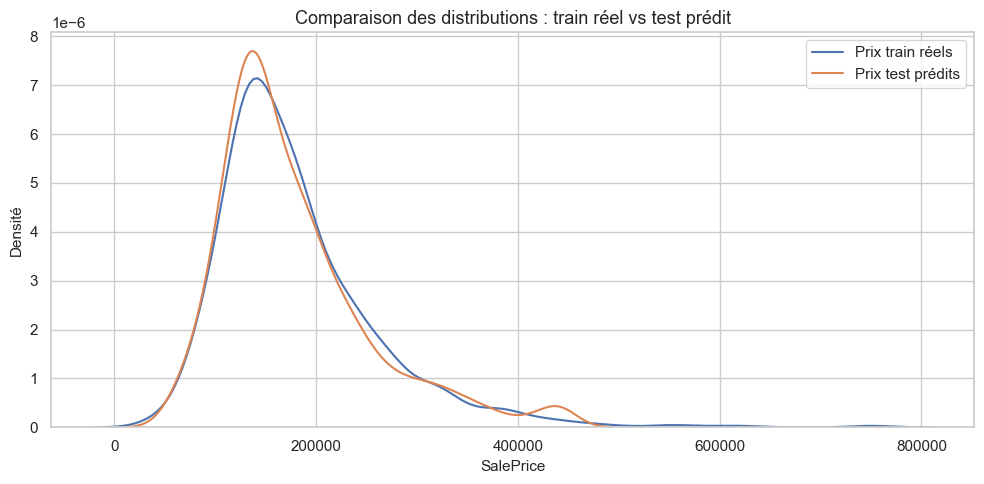

,train_reel,test_predit
count,1458.0,1459.0
mean,180933.0,177913.0
std,79495.0,75550.0
min,34900.0,61785.0
5%,88000.0,90188.0
50%,163000.0,156289.0
95%,326300.0,337915.0
max,755000.0,442681.0


Interprétation : les deux distributions ne doivent pas être identiques, mais elles doivent rester dans des ordres de grandeur plausibles.


In [22]:
# Comparaison entre la distribution des prix d'entraînement et celle des prédictions test.
# On reconvertit y en prix pour comparer les ordres de grandeur.
train_prices_approx = np.expm1(y)

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(train_prices_approx, label='Prix train réels', ax=ax)
sns.kdeplot(final_prices, label='Prix test prédits', ax=ax)
ax.set_title('Comparaison des distributions : train réel vs test prédit')
ax.set_xlabel('SalePrice')
ax.set_ylabel('Densité')
ax.legend()
plt.tight_layout()
plt.show()

comparison_distribution = pd.DataFrame({
    'train_reel': pd.Series(train_prices_approx).describe(percentiles=[0.05, 0.5, 0.95]),
    'test_predit': pd.Series(final_prices).describe(percentiles=[0.05, 0.5, 0.95])
}).round(0)

display(comparison_distribution)

print("Interprétation : les deux distributions ne doivent pas être identiques, mais elles doivent rester dans des ordres de grandeur plausibles.")

## 10. Export du fichier de soumission Kaggle

Le fichier final doit contenir exactement deux colonnes :

```text
Id, SalePrice
```

Le notebook vérifie aussi :

- le nombre de lignes ;
- l'absence de valeurs manquantes ;
- l'absence de valeurs infinies ;
- le format correct des colonnes.


In [23]:
submission = pd.DataFrame({'Id': test_ID.values, 'SalePrice': final_prices})

assert submission.shape[0] == test_n_rows,       'Row count mismatch'
assert list(submission.columns) == ['Id', 'SalePrice'], 'Column mismatch'
assert submission['SalePrice'].notna().all(),           'NaN predictions'
assert np.isfinite(submission['SalePrice']).all(),       'Inf predictions'

# Sortie locale : on sauvegarde une version spécifique à cette expérience.
# Cela évite d'écraser les autres soumissions pendant les tests Kaggle.
output_path = Path('final_submission_04C_5fold.csv')
submission.to_csv(output_path, index=False)

# Compatibilité : on garde aussi l'ancien nom utilisé par les notebooks précédents.
compat_output_path = Path('final_submission_cv.csv')
submission.to_csv(compat_output_path, index=False)

print('Fichier de soumission spécifique enregistré :', output_path.resolve())
print('Copie compatible enregistrée :', compat_output_path.resolve())
print('Variante : 04C — Modèles avec 5 folds')
print('\nTaille de la soumission :', submission.shape)
display(submission.head())

print('\nDistribution des prix prédits :')
display(submission['SalePrice'].describe().round(0))


Fichier de soumission spécifique enregistré : C:\Users\souma\OneDrive\Bureau\proj ML\projet\final\final_submission_04C_5fold.csv
Copie compatible enregistrée : C:\Users\souma\OneDrive\Bureau\proj ML\projet\final\final_submission_cv.csv
Variante : 04C — Modèles avec 5 folds

Taille de la soumission : (1459, 2)


,Id,SalePrice
0,1461,120188.140733
1,1462,158697.094721
2,1463,180911.273752
3,1464,195745.659835
4,1465,188684.509698



Distribution des prix prédits :


count      1459.0
mean     177913.0
std       75550.0
min       61785.0
25%      127431.0
50%      156289.0
75%      208583.0
max      442681.0
Name: SalePrice, dtype: float64

## 11. Synthèse finale

Ce notebook applique une stratégie complète de modélisation :

- plusieurs modèles de base pour diversifier les erreurs ;
- validation OOF pour évaluer proprement chaque modèle ;
- blend optimisé pour combiner les prédictions ;
- stacking léger pour améliorer la combinaison sans trop surapprendre ;
- assemblage final conservateur ;
- export Kaggle propre.

Le fichier à soumettre est :

```text
final_submission_cv.csv
```

La logique de prédiction et le nom du fichier de sortie sont conservés.
